In [5]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tabulate import tabulate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [6]:

df = pd.read_csv('Phishing_Email.csv', encoding='ISO-8859-1')
df = df[['label', 'text']]

label_counts = df['label'].value_counts()

In [7]:
# 2. Find Missing Values
missing_text_count = df['text'].isnull().sum()
print(f"Number of missing values in 'text' column: {missing_text_count}")

Number of missing values in 'text' column: 16


In [8]:
# 3. Treat Missing Values
if missing_text_count > 0:
    df['text'].fillna('', inplace=True)
    print("Missing values in 'text' column filled with empty strings.")
else:
    print("No missing values found in 'text' column.")

Missing values in 'text' column filled with empty strings.


/tmp/ipykernel_17874/1767109224.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['text'].fillna('', inplace=True)


In [9]:
# 4. Create 'label_num'
unique_labels = df['label'].unique()
label_map = {label: i for i, label in enumerate(unique_labels)}
df['label_num'] = df['label'].map(label_map)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label_num'], test_size=0.3, random_state=42)


In [11]:
# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('classifier', MultinomialNB())
])

In [12]:
# Train the model
pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [13]:
# Make predictions on the training set
y_train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

In [14]:
# Make predictions on the test set
y_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

In [15]:
# Create table
table = [
    ["Model", "Train Accuracy", "Test Accuracy"],
    ["MultinomialNB", train_accuracy, test_accuracy],
]
print(tabulate(table, headers="firstrow", tablefmt="grid"))

+---------------+------------------+-----------------+
| Model         |   Train Accuracy |   Test Accuracy |
+===============+==================+=================+
| MultinomialNB |         0.948142 |        0.915996 |
+---------------+------------------+-----------------+


In [16]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(tabulate(df_report, headers='keys', tablefmt='grid'))

Accuracy: 0.9160
+--------------+-------------+----------+------------+-------------+
|              |   precision |   recall |   f1-score |     support |
+==============+=============+==========+============+=============+
| 0            |    0.879499 | 0.997633 |   0.934849 | 3380        |
+--------------+-------------+----------+------------+-------------+
| 1            |    0.995457 | 0.791422 |   0.881791 | 2215        |
+--------------+-------------+----------+------------+-------------+
| accuracy     |    0.915996 | 0.915996 |   0.915996 |    0.915996 |
+--------------+-------------+----------+------------+-------------+
| macro avg    |    0.937478 | 0.894528 |   0.90832  | 5595        |
+--------------+-------------+----------+------------+-------------+
| weighted avg |    0.925406 | 0.915996 |   0.913844 | 5595        |
+--------------+-------------+----------+------------+-------------+


Confusion Matrix:
 [[3372    8]
 [ 462 1753]]


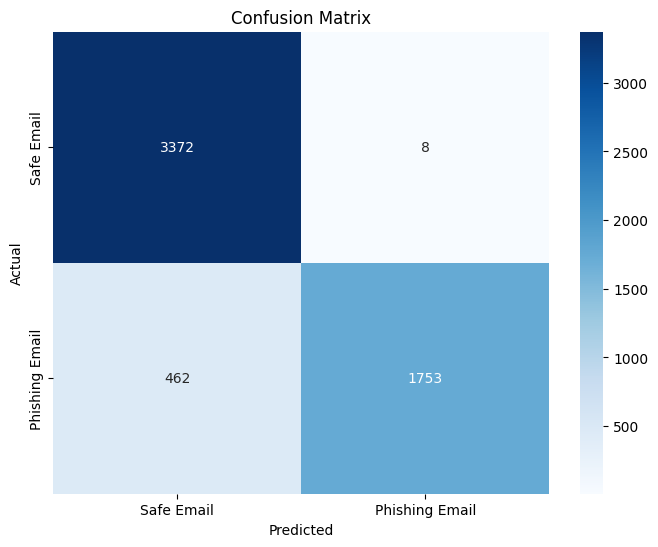

In [17]:
# 7. Evaluate and Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualize the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()